# Preprocessing

## Prepare

In [67]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer

In [68]:
train = pd.read_csv('../../data/raw/train.csv')
test = pd.read_csv('../../data/raw/test.csv')

## Remove duplicate

In [69]:
train[train.duplicated(subset = train.columns.difference(['class']))]

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class


In [70]:
test[test.duplicated(subset = test.columns.difference(['class']))]

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature


In [71]:
train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

## Fill missing value.

**There are three feature have missing value.**
+ Popularity
+ key
+ instrumentalness

Cột Popularity và instrumentalness có các giá trị ngoại lai nên ta có thể điền median, vì median không ảnh hưởng bởi các giá trị ngoại lai.

In [72]:
imp = SimpleImputer (missing_values = np.nan , strategy = 'median')
train[['Popularity', 'instrumentalness']] = imp.fit_transform(train[['Popularity', 'instrumentalness']])
test[['Popularity', 'instrumentalness']] = imp.transform(test[['Popularity', 'instrumentalness']])

Với key nếu điền cái giá trị như median và mean thì có thể làm sai dữ liệu. Đồng thời key cũng là 1 biến phân loại nên ta sẽ điền -1 cho các giá trị còn thiếu.

In [73]:
imp = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value = -1)
train[['key']] = imp.fit_transform(train[['key']])
test[['key']] = imp.transform(test[['key']])

In [74]:
train.isnull().sum()
test.isnull().sum()

Id                    0
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
dtype: int64

## Treat outliers

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_skewness(df):
    # 1. Lọc ra các cột số (loại bỏ cột tên bài hát, tên nghệ sĩ...)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Loại bỏ cột 'key' và 'mode' vì chúng là biến phân loại (categorical)
    cols_to_exclude = ['key', 'mode', 'time_signature']
    numeric_cols = [c for c in numeric_cols if c not in cols_to_exclude]

    # 2. Tính toán chỉ số Skewness
    skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
    
    print("--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) ---")
    print(skew_vals)
    print("\n" + "="*40 + "\n")

    # 3. Vẽ biểu đồ trực quan
    # Tính toán số hàng cần thiết cho lưới biểu đồ
    n_cols_plot = 3  
    n_rows_plot = (len(numeric_cols) + n_cols_plot - 1) // n_cols_plot

    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
    axes = axes.flatten() # Làm phẳng mảng axes để dễ lặp

    for i, col in enumerate(numeric_cols):
        # Vẽ Histogram kèm đường cong mật độ (KDE)
        sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
        
        # Vẽ đường Trung bình (Mean) và Trung vị (Median) để thấy rõ độ lệch
        axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean (TB)')
        axes[i].axvline(df[col].median(), color='green', linestyle='-', label='Median (TV)')
        
        # Tiêu đề hiển thị tên cột và giá trị Skew
        axes[i].set_title(f'{col}\nSkew: {round(skew_vals[col], 2)}', fontsize=12, fontweight='bold')
        axes[i].legend()

    # Tắt các ô biểu đồ thừa (nếu có)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) ---
speechiness           3.113395
liveness              2.178265
instrumentalness      1.972589
acousticness          1.108933
duration_in min/ms    0.836407
tempo                 0.376507
valence               0.088687
Popularity            0.078797
Id                    0.000000
danceability         -0.075651
energy               -0.656698
Class                -0.666563
loudness             -1.748073
dtype: float64




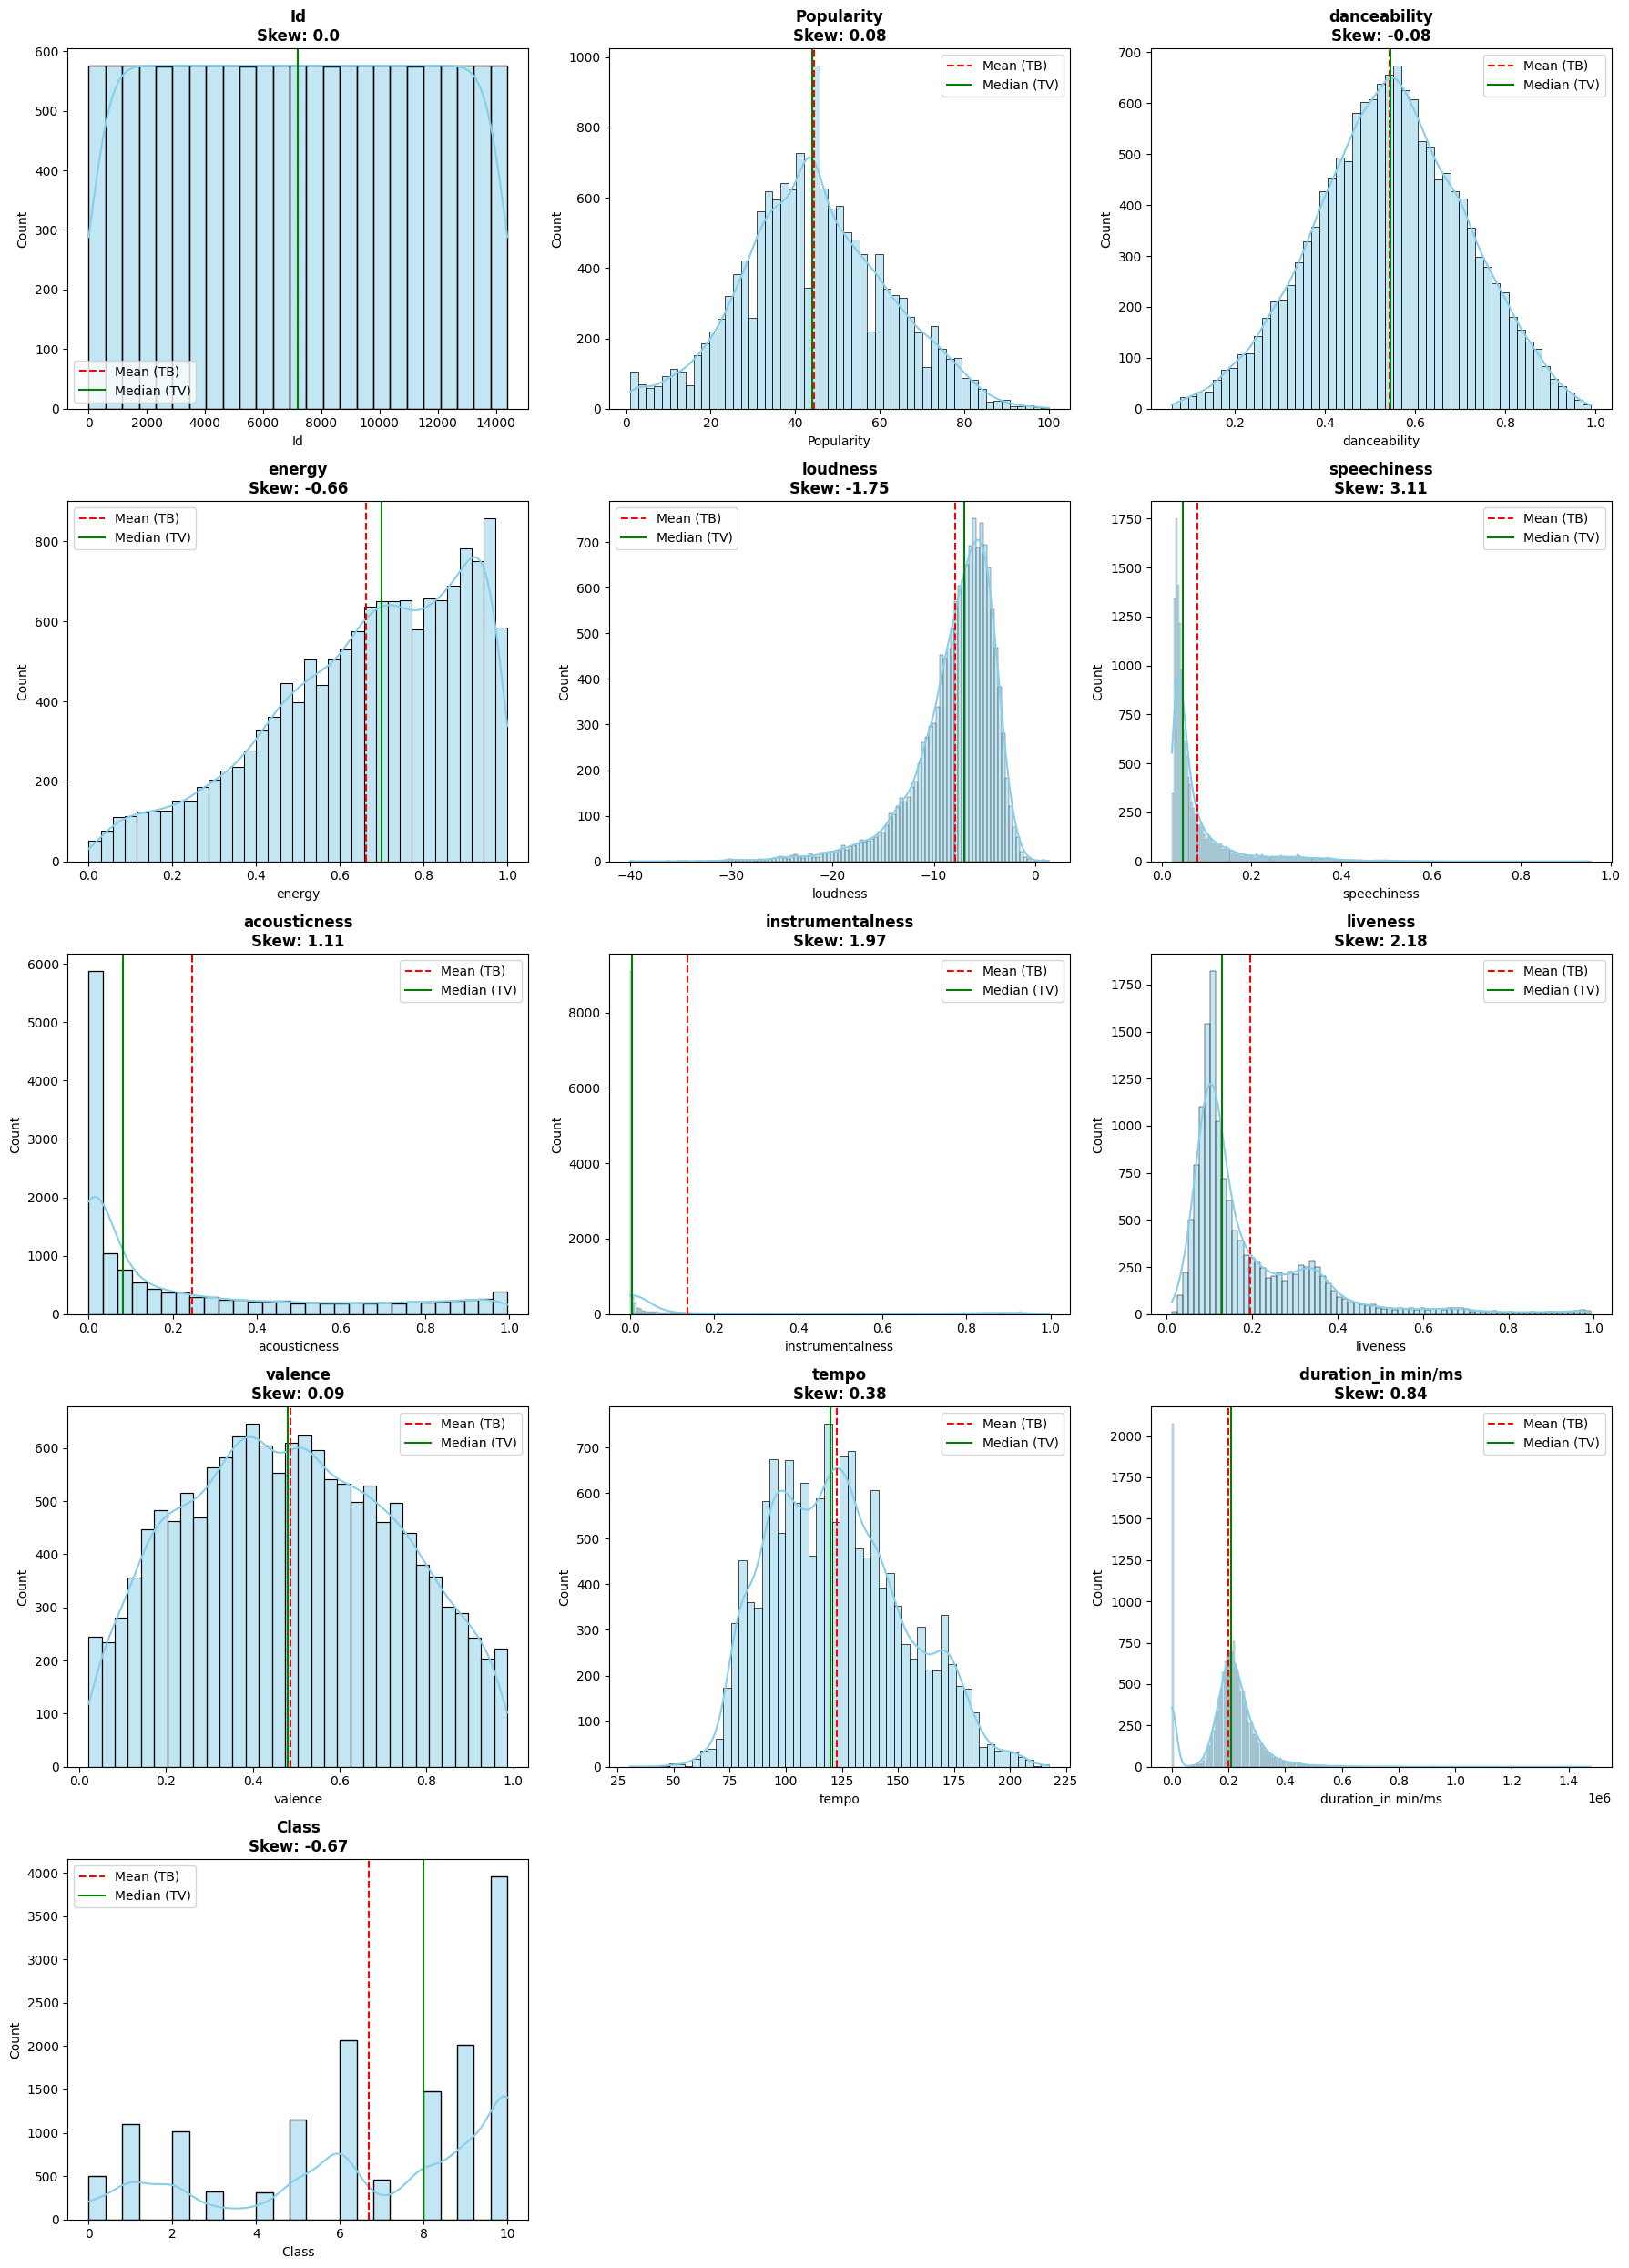

In [76]:
analyze_skewness(train)

In [ ]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)
train[['energy', 'loudness', 'liveness', 'tempo']] = pt.fit_transform(train[['energy', 'loudness', 'liveness', 'tempo']])
test[['energy', 'loudness', 'liveness', 'tempo']] = pt.transform(test[['energy', 'loudness', 'liveness', 'tempo']])


In [ ]:
train['instrumentalness'] = np.log1p(train['instrumentalness'])
test['instrumentalness'] = np.log1p(test['instrumentalness'])

--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) ---
speechiness           3.113395
instrumentalness      1.240299
acousticness          0.430075
liveness              0.324864
valence               0.088687
Popularity            0.078797
loudness              0.014902
Id                    0.000000
tempo                -0.010150
danceability         -0.075651
energy               -0.162370
Class                -0.666563
duration_in min/ms   -1.302565
dtype: float64




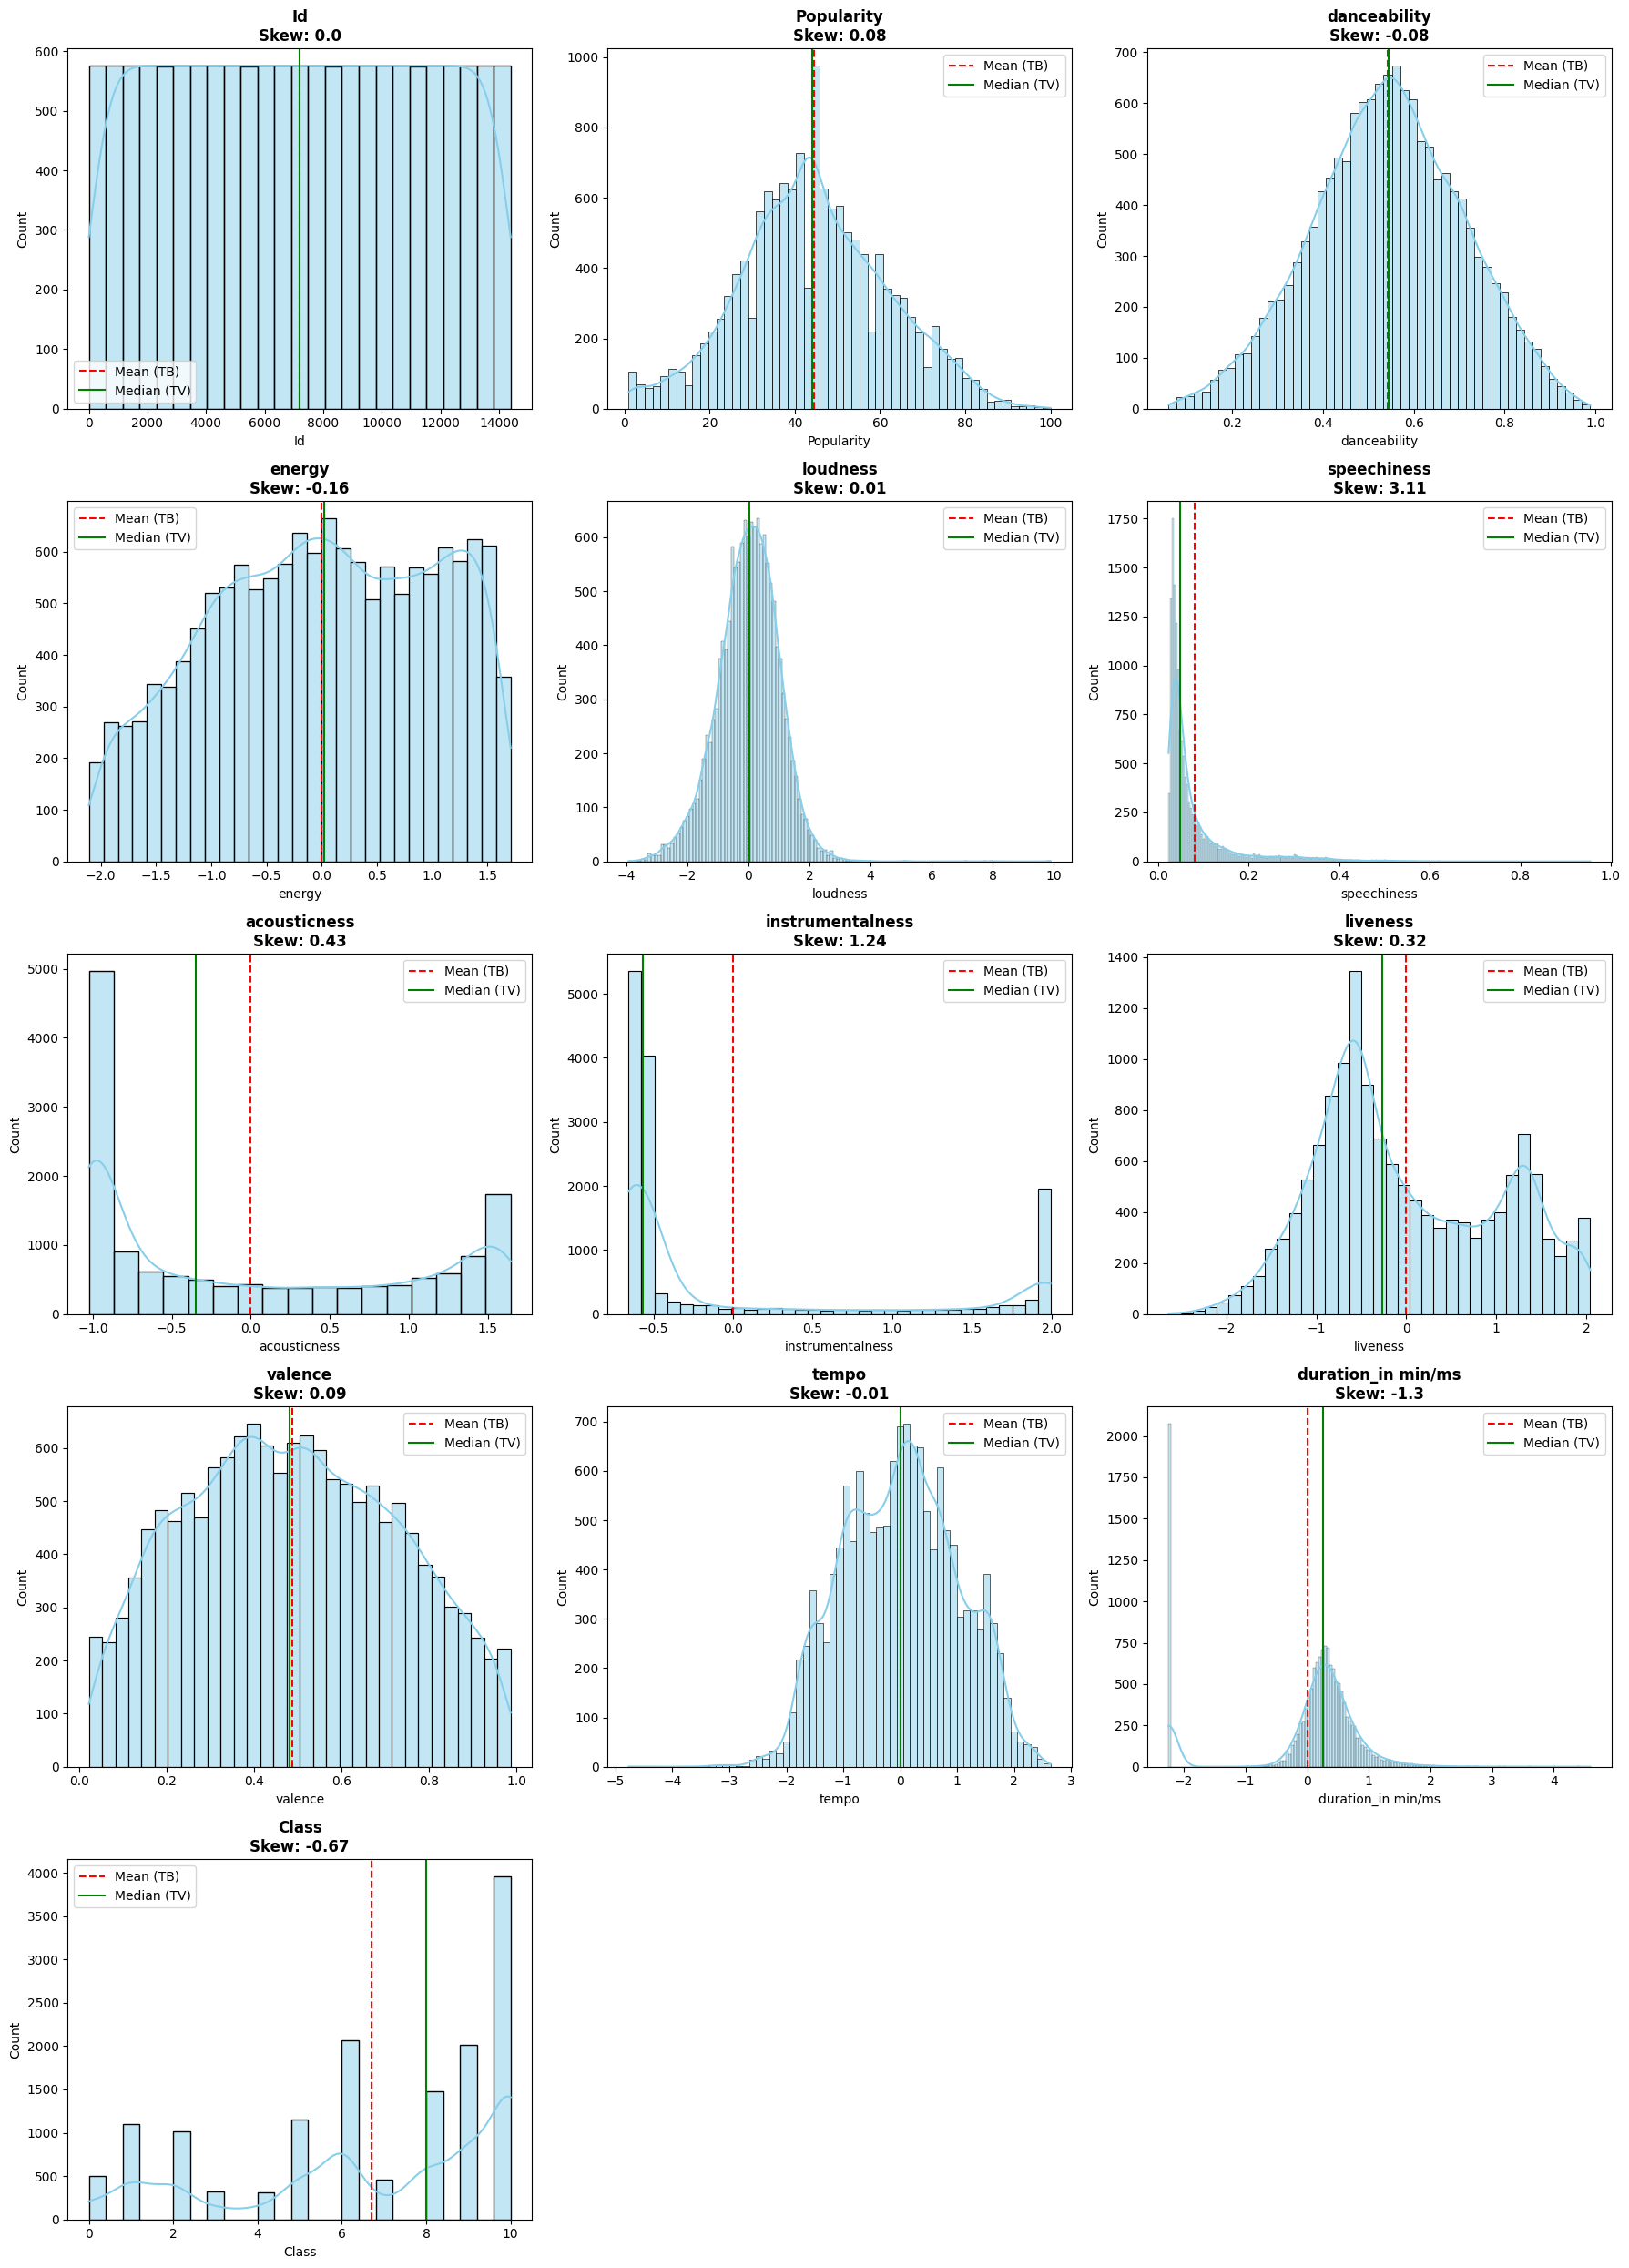

In [78]:
analyze_skewness(train)